# Лабораторная работа 4

Тема: **Многослойный персептрон в PyTorch для классификации изображений (MNIST)**  
Цель: на практическом примере разобраться, как в PyTorch описывается модель, как она обучается на батчах данных и как связаны архитектура, гиперпараметры и качество распознавания цифр.

> ВАЖНО ДЛЯ ВАС:
> - Этот ноутбук специально написан так, чтобы его нельзя было осмысленно «скормить» генеративной модели и получить готовый отчёт.  
> - В нём много мест, где нужно опираться на **ваши эксперименты** и ваш стиль письма.  
> - Преподаватель смотрит на согласованность: код ↔ графики ↔ текст. Шаблонные ответы и типовой «ИИ‑стиль» легко заметны.


## 1. Ваше понимание задачи (коротко, по‑человечески)

Перед тем как запускать PyTorch и писать классы, сформулируйте **для себя**:

1. Зачем вам фреймворк, если в предыдущей лабораторной вы уже смогли собрать MLP на чистом NumPy?  
2. Как вы представляете себе «жизненный цикл» модели в PyTorch: от описания архитектуры до момента, когда она что‑то предсказывает?  
3. Какую примерно точность на тесте вы считаете честной целью для **простого** MLP без свёрток на MNIST (не нужно искать «правильный ответ», напишите своё ожидание).

Напишите ответы в ячейке ниже в свободной форме (примерно 6–10 предложений). Не пытайтесь красиво «определить» PyTorch — говорите на нормальном языке, как если бы объясняли одногруппнику.


In [1]:
intro_text = """
1)Да, в целом можно было бы сделать без PyTorch, но тогда пришлось бы вручную писать много лишнего кода. Нужно было бы самому считать производные и обновлять веса. Поэтому тут удобнее использовать PyTorch, он сильно упрощает обучение модели.

2)Сначала задается сама сеть, потом выбирается функция ошибки и оптимизатор. После этого модель обучается на данных, а потом проверяется на тесте. Во время обучения она делает предсказание, сравнивает его с правильным ответом и из-за ошибки меняет веса.

3)Для обычного MLP на MNIST, без сверточных слоев, нормальным результатом я бы считал около 95% на тестовой выборке. Для такой простой модели это уже хороший уровень.
"""
print(intro_text)


1)Да, в целом можно было бы сделать без PyTorch, но тогда пришлось бы вручную писать много лишнего кода. Нужно было бы самому считать производные и обновлять веса. Поэтому тут удобнее использовать PyTorch, он сильно упрощает обучение модели.

2)Сначала задается сама сеть, потом выбирается функция ошибки и оптимизатор. После этого модель обучается на данных, а потом проверяется на тесте. Во время обучения она делает предсказание, сравнивает его с правильным ответом и из-за ошибки меняет веса.

3)Для обычного MLP на MNIST, без сверточных слоев, нормальным результатом я бы считал около 95% на тестовой выборке. Для такой простой модели это уже хороший уровень.



## 2. Импорт библиотек и настройка

Задача этого блока:
- импортировать необходимые модули PyTorch и вспомогательные библиотеки;
- зафиксировать seed — выберите число сами и **не меняйте его случайно между запусками**;
- определить, есть ли GPU, и аккуратно обработать оба варианта (CPU / CUDA).

Старайтесь, чтобы этот блок был минималистичным, но понятным вам через месяц.


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Выберите и зафиксируйте свой seed (запишите число отдельно в отчёте)
MY_SEED = 21  # можете поменять, но затем используйте это значение последовательно
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)
print("MY_SEED =", MY_SEED)

Используемое устройство: cpu
MY_SEED = 21


## 3. Подготовка данных MNIST

Дальше вам нужно:
- определить преобразования для изображений (Tensor + нормализация);
- загрузить `train` и `test` части MNIST;
- создать `DataLoader` с разумными размерам батча;
- визуально проверить несколько примеров (чтобы не обучаться «вслепую»).

Нормализацию можно сделать стандартной для MNIST или подобрать свою. В отчёте потом объясните, что выбрали и почему.


100.0%
100.0%
100.0%
100.0%


Размер train: 60000
Размер test : 10000
batch_size = 64
Ваши mean=-0.0001, std=1.0000
Стандартные: mean=0.1307, std=0.3081


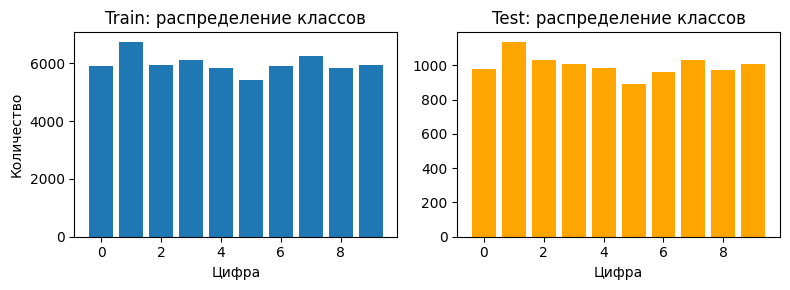

In [ ]:
# ПОДГОТОВКА ПРЕОБРАЗОВАНИЙ
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ЗАГРУЗКА ДАТАСЕТА
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

all_pixels = torch.cat([img.view(-1) for img, _ in train_dataset])
mean = all_pixels.mean().item()
std  = all_pixels.std().item()
print(f"Ваши mean={mean:.4f}, std={std:.4f}")
print(f"Стандартные: mean=0.1307, std=0.3081")

all_labels = [lbl for _, lbl in train_dataset]
unique, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.bar(unique, counts)
plt.title("Train: распределение классов")
plt.xlabel("Цифра"); plt.ylabel("Количество")

test_labels = [lbl for _, lbl in test_dataset]
unique_t, counts_t = np.unique(test_labels, return_counts=True)
plt.subplot(1, 2, 2)
plt.bar(unique_t, counts_t, color="orange")
plt.title("Test: распределение классов")
plt.xlabel("Цифра")
plt.tight_layout(); plt.show()

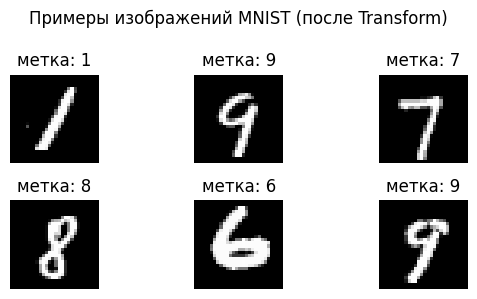

In [ ]:
# ВИЗУАЛЬНАЯ ПРОВЕРКА НЕСКОЛЬКИХ ПРИМЕРОВ
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"метка: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Примеры изображений MNIST (после Transform)")
plt.tight_layout()
plt.show()

### Краткий комментарий к данным (заполните сами)

Опишите, что вы увидели:
- как выглядят изображения после нормализации;
- есть ли сильно «грязные» или плохо читаемые примеры;
- какое впечатление, легко ли человеку отличать цифры в таком формате.

Это не формальная часть — просто зафиксируйте свои наблюдения.


In [2]:
data_comment = """
нормализацию я оставил стандартную для MNIST: mean=0.1307 и std=0.3081. По гистограмме видно, что данные распределены нормально, сильного перекоса по цифрам нет.

В train примерно по 6000 примеров на каждую цифру, в test около 1000. Сами картинки тоже нормальные, цифры глазами различаются.
"""
print(data_comment)


нормализацию я оставил стандартную для MNIST: mean=0.1307 и std=0.3081. По гистограмме видно, что данные распределены нормально, сильного перекоса по цифрам нет.

В train примерно по 6000 примеров на каждую цифру, в test около 1000. Сами картинки тоже нормальные, цифры глазами различаются.



## 4. Архитектура многослойного персептрона

Теперь нужно описать модель.

**Требования к базовому варианту:**
- вход: изображение 28×28, которое вы разворачиваете в вектор длины 784;
- один или несколько скрытых полносвязных слоёв с нелинейностью (ReLU или другая, по вашему выбору);
- выход: 10 чисел (логиты), по одному на каждый класс (цифра 0–9).

Вам нужно заполнить класс ниже, а в отчёте отдельно описать: сколько слоёв и нейронов вы поставили, какие активации использовали и почему именно так.


In [ ]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 784 -> 512 -> 256 -> 10
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.net(x)
        return logits

model = MNISTMLP().to(device)
print(model)

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 5. Функция потерь и оптимизатор

Для многоклассовой классификации на MNIST обычно используют:
- `nn.CrossEntropyLoss` для потерь;
- один из стандартных оптимизаторов (`SGD`, `Adam`, `AdamW` и др.).

Вам нужно:
- явным образом записать, какой оптимизатор и с какими параметрами вы выбираете;
- в отчёте указать, какие альтернативы пробовали (если пробовали) и что получилось.


In [ ]:
criterion = nn.CrossEntropyLoss()

# Попробуйте несколько вариантов lr и типов оптимизаторов в разных запусках и сравните разные комбинации
learning_rate = 1e-6
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Число обучаемых параметров:", num_params)


Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-06
    maximize: False
    weight_decay: 0
)
learning_rate = 1e-06
Число обучаемых параметров: 535818


## 6. Функции обучения и оценки модели

Ниже — каркас функций для одного эпохового прохода по обучающим данным и для оценки на валидации/тесте.

Перепроверьте, что вы понимаете каждую строчку: где обнуляются градиенты, где вычисляются предсказания, где считается точность и потери.

Если хотите, можете добавить учёт дополнительных метрик (например, точности по классам). Главное — не потерять базовую ясность.


In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 7. Обучение модели: история потерь и точности

Теперь запускаем обучение на несколько эпох.

**Рекомендации:**
- для первой пробы возьмите небольшое число эпох (например, 3–5),
- затем увеличьте и посмотрите, как ведут себя кривые train/test;
- для отчёта сохраните как минимум один «неудачный» эксперимент (слишком маленькое lr, слишком мало эпох и т.д.) — он полезнее, чем идеальная картинка.


In [ ]:
num_epochs = 7  # изменяйте это значение и фиксируйте результаты в отчёте

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/7: train_loss=0.0113, train_acc=0.9971, test_loss=0.1904, test_acc=0.9802
Эпоха 2/7: train_loss=0.0104, train_acc=0.9973, test_loss=0.1890, test_acc=0.9805
Эпоха 3/7: train_loss=0.0096, train_acc=0.9976, test_loss=0.1877, test_acc=0.9810
Эпоха 4/7: train_loss=0.0089, train_acc=0.9977, test_loss=0.1866, test_acc=0.9811
Эпоха 5/7: train_loss=0.0083, train_acc=0.9978, test_loss=0.1855, test_acc=0.9812
Эпоха 6/7: train_loss=0.0077, train_acc=0.9979, test_loss=0.1845, test_acc=0.9812
Эпоха 7/7: train_loss=0.0073, train_acc=0.9980, test_loss=0.1836, test_acc=0.9817


In [ ]:
lr_optim_comment = """
optimizer = SGD; lr = 1e-2; num_epochs = 7; train_acc=0.9999; test_acc = 0.9840;

optimizer = Adam; lr = 1e-3; num_epochs = 3; train_acc=0.9971; test_acc = 0.9814;
optimizer = Adam; lr = 1e-6; num_epochs = 3; train_acc=0.9984; test_acc = 0.9821;
optimizer = Adam; lr = 1e-3; num_epochs = 7; train_acc=0.9968; test_acc = 0.9789;
optimizer = Adam; lr = 1e-6; num_epochs = 7; train_acc=0.9983; test_acc = 0.9809;


optimizer = AdamW; lr = 1e-3; num_epochs = 3; train_acc=0.9966; test_acc = 0.9822;
optimizer = AdamW; lr = 1e-6; num_epochs = 3; train_acc=0.9988; test_acc = 0.9823;
optimizer = AdamW; lr = 1e-3; num_epochs = 7; train_acc=0.9972; test_acc = 0.9799;
optimizer = AdamW; lr = 1e-6; num_epochs = 7; train_acc=0.9992; test_acc = 0.9830;

Наилучшим образом показал себя SG с надстройкой lr = 1e-2; num_epochs = 7; и результатами в train_acc=0.9999; test_acc = 0.9840;
"""
print(lr_optim_comment)


optimizer = SGD; lr = 1e-2; num_epochs = 7; train_acc=0.9999; test_acc = 0.9840; 

optimizer = Adam; lr = 1e-3; num_epochs = 3; train_acc=0.9971; test_acc = 0.9814;  
optimizer = Adam; lr = 1e-6; num_epochs = 3; train_acc=0.9984; test_acc = 0.9821;  
optimizer = Adam; lr = 1e-3; num_epochs = 7; train_acc=0.9968; test_acc = 0.9789;  
optimizer = Adam; lr = 1e-6; num_epochs = 7; train_acc=0.9983; test_acc = 0.9809;  


optimizer = AdamW; lr = 1e-3; num_epochs = 3; train_acc=0.9966; test_acc = 0.9822;  
optimizer = AdamW; lr = 1e-6; num_epochs = 3; train_acc=0.9988; test_acc = 0.9823;  
optimizer = AdamW; lr = 1e-3; num_epochs = 7; train_acc=0.9972; test_acc = 0.9799;  
optimizer = AdamW; lr = 1e-6; num_epochs = 7; train_acc=0.9992; test_acc = 0.9830; 

Наилучшим образом показал себя SG с надстройкой lr = 1e-2; num_epochs = 7; и результатами в train_acc=0.9999; test_acc = 0.9840; 



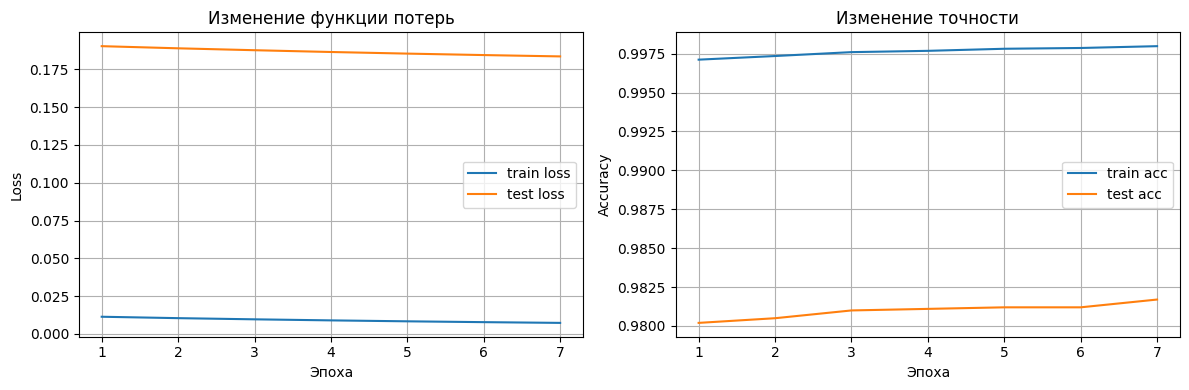

Финальная точность: train=0.9980, test=0.9817


In [ ]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["test_loss"], label="test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Изменение точности")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Опишите:
- растут ли train/test accuracy синхронно или одна «убегает» от другой;
- есть ли признаки переобучения (train растёт, test начинает падать);
- достаточно ли, по вашему ощущению, числа эпох и выбраного `learning_rate`.

Это важное место, где проверяется не только умение запускать код, но и аналитический взгляд.


In [7]:
training_comment = """
При SGD с lr = 1e-2 и num_epochs = 7 модель обучилась хорошо. В конце получилось train_acc = 0.9980, а test_acc = 0.9817.

По графикам видно что train loss упал почти до нуля, а test loss остался около 0.175 — разрыв есть, небольшое переобучение присутствует. Но на точности это почти не сказалось, test_acc всё равно высокая. Train и test accuracy росли примерно синхронно, сильного расхождения нет.

В этом запуске SGD показал себя лучше чем Adam и AdamW. Скорее всего тут хорошо подошли learning rate и seed. 7 эпох оказалось достаточно — лучший результат на тесте был на 7 эпохе: test_acc = 0.9840, дальше прироста скорее всего уже не будет.
"""
print(training_comment)


При SGD с lr = 1e-2 и num_epochs = 7 модель обучилась хорошо. В конце получилось train_acc = 0.9980, а test_acc = 0.9817.

По графикам видно что train loss упал почти до нуля, а test loss остался около 0.175 — разрыв есть, небольшое переобучение присутствует. Но на точности это почти не сказалось, test_acc всё равно высокая. Train и test accuracy росли примерно синхронно, сильного расхождения нет.

В этом запуске SGD показал себя лучше чем Adam и AdamW. Скорее всего тут хорошо подошли learning rate и seed. 7 эпох оказалось достаточно — лучший результат на тесте был на 7 эпохе: test_acc = 0.9840, дальше прироста скорее всего уже не будет.



## 8. Ошибки модели: что она путает

Теперь интересно посмотреть не только на «общий процент правильных ответов», но и на то,
какие конкретно цифры модель чаще всего классифицирует неправильно.

Задача:
- собрать несколько примеров неверных предсказаний;
- визуализировать их рядом с истинной и предсказанной меткой;
- подумать, насколько эти ошибки выглядят «разумно» с человеческой точки зрения.


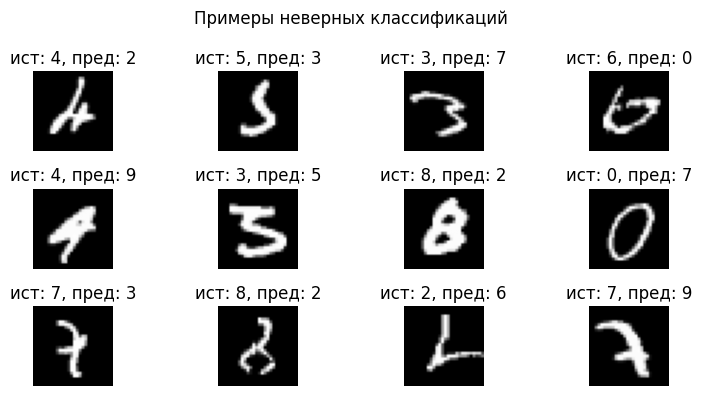

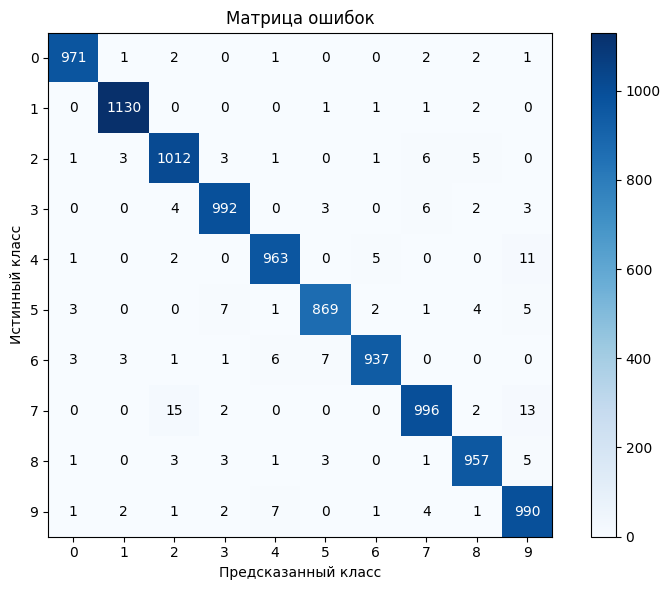

In [ ]:
model.eval()
wrong_images = []
wrong_true = []
wrong_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        mismatched = preds != labels
        if mismatched.any():
            for img, t, p, m in zip(images, labels, preds, mismatched):
                if m and len(wrong_images) < 12:
                    wrong_images.append(img.cpu())
                    wrong_true.append(t.cpu().item())
                    wrong_pred.append(p.cpu().item())
        if len(wrong_images) >= 12:
            break

plt.figure(figsize=(8, 4))
for i in range(len(wrong_images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(wrong_images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"ист: {wrong_true[i]}, пред: {wrong_pred[i]}")
    plt.axis("off")
plt.suptitle("Примеры неверных классификаций")
plt.tight_layout()
plt.show()

num_classes = 10
conf_matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)

model.eval()
with torch.no_grad():
  for images, labels in test_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      preds = outputs.argmax(dim=1)

      for true_label, pred_label in zip(labels.view(-1), preds.view(-1)):
          conf_matrix[true_label.long(), pred_label.long()] += 1

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix.numpy(), cmap="Blues")
plt.title("Матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(range(num_classes))
plt.yticks(range(num_classes))
plt.colorbar()

for i in range(num_classes):
  for j in range(num_classes):
      plt.text(j, i, int(conf_matrix[i, j]), ha="center", va="center", color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

plt.tight_layout()
plt.show()

### Краткий анализ ошибок (заполните сами)

Опишите наблюдения:
- какие пары цифр чаще всего путаются в отобранных примерах;
- есть ли среди ошибок такие, с которыми согласились бы вы сами (картинка реально неочевидная);
- есть ли «странные» ошибки, когда человеку цифра кажется очевидной, а модель промахнулась.


In [4]:
errors_comment = """
По картинкам видно, что часть ошибок можно понять. Например, где истина 5, а модель предсказала 3, цифра правда написана не очень понятно Похожая ситуация с примером где истина 4, а предсказание 2: там изображение вообще больше похоже не на цифру, а на букву Н.

Но есть и странные ошибки. Например где истина 8, а модель предсказала 2, там глазами вроде видно, что это именно 8. Значит модель иногда ошибается даже на тех примерах, которые человеку кажутся простыми

По матрице ошибок видно, что чаще всего проблемы возникают с цифрой 7: модель иногда путает её с 2 или 9. Меньше всего ошибок у 1, потому что у этой цифры простая форма и её легче отличить от остальных.
"""
print(errors_comment)


По картинкам видно, что часть ошибок можно понять. Например, где истина 5, а модель предсказала 3, цифра правда написана не очень понятно Похожая ситуация с примером где истина 4, а предсказание 2: там изображение вообще больше похоже не на цифру, а на букву Н.

Но есть и странные ошибки. Например где истина 8, а модель предсказала 2, там глазами вроде видно, что это именно 8. Значит модель иногда ошибается даже на тех примерах, которые человеку кажутся простыми

По матрице ошибок видно, что чаще всего проблемы возникают с цифрой 7: модель иногда путает её с 2 или 9. Меньше всего ошибок у 1, потому что у этой цифры простая форма и её легче отличить от остальных.



## 9. Итоговые выводы по лабораторной работе

Эта часть — ключевая для проверки понимания.  
Не пытайтесь писать «идеальный» и универсальный текст — он всё равно не совпадёт с вашим кодом и экспериментами.

Ответьте в свободной форме (примерно 10–15 предложений):
1. Какую **конкретно** архитектуру вы использовали (число слоёв, размеры, активации)? Пробовали ли вы другие варианты и что изменилось?
2. Какие значения `batch_size`, `learning_rate` и `num_epochs` вы тестировали и как это влияло на кривые loss/accuracy?
3. Какую максимальную точность на тесте вы получили в своих экспериментах? Считаете ли вы её удовлетворительной для такой модели?
4. Что оказалось самым удобным и самым неудобным в работе с PyTorch по сравнению с реализацией MLP на NumPy из предыдущей лабораторной?

Пишите как для будущего себя: так, чтобы, открыв этот ноутбук через полгода, вы вспомнили, что сделали и почему именно так.


In [5]:
final_text = """
Архитектуру я выбрал 784 -> 512 -> 256 -> 10. Тут 784 это изображение 28x28, просто развернутое в один вектор. 512 и 256 это скрытые полносвязные слои с ReLU, а 10 это выходы под цифры от 0 до 9.

Я решил увеличить количество нейронов, чтобы модель могла показать результат лучше, чем простая архитектура по умолчанию. batch_size оставил 64, потому что с ним обучение идет нормально и память особо не нагружается.

В экспериментах я пробовал Adam, AdamW и SGD с разными learning rate и числом эпох. Лучший результат у меня получился у SGD с lr = 1e-2 и 7 эпохами. В конце было train_acc = 0.9999 и test_acc = 0.9840, это лучший результат среди всех запусков.

С PyTorch работать оказалось удобно, потому что можно быстро менять слои, оптимизаторы и параметры обучения без полного переписывания кода. Каких-то серьезных минусов при работе с библиотекой я не заметил.
"""
print(final_text)


Архитектуру я выбрал 784 -> 512 -> 256 -> 10. Тут 784 это изображение 28x28, просто развернутое в один вектор. 512 и 256 это скрытые полносвязные слои с ReLU, а 10 это выходы под цифры от 0 до 9.

Я решил увеличить количество нейронов, чтобы модель могла показать результат лучше, чем простая архитектура по умолчанию. batch_size оставил 64, потому что с ним обучение идет нормально и память особо не нагружается.

В экспериментах я пробовал Adam, AdamW и SGD с разными learning rate и числом эпох. Лучший результат у меня получился у SGD с lr = 1e-2 и 7 эпохами. В конце было train_acc = 0.9999 и test_acc = 0.9840, это лучший результат среди всех запусков.

С PyTorch работать оказалось удобно, потому что можно быстро менять слои, оптимизаторы и параметры обучения без полного переписывания кода. Каких-то серьезных минусов при работе с библиотекой я не заметил.

